This analysis investigates whether the COVID-19 pandemic led to measurable changes in Conservation values (Security, Conformity, Tradition) and Political Trust in Europe.

We compare ESS Round 9 (2018) as the pre-pandemic baseline and Round 11 (2024) for the post-pandemic landscape.

*Note on Data Limitation: In Round 11, Schwartz Human Value variables (Conservation items) are largely missing in the current subset. Therefore, the long-term trend analysis for values will focus on Round 9 vs. Round 10, while Political Trust will be analyzed across all three rounds.*

## Import and Data Load

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("ess_cleaned_data.csv")
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (136454, 45)


,idno,cntry,essround,yrbrn,agea,gndr,anweight,lrscale,trstprl,trstplt,...,Benevolence,Tradition,Security,Conformity,Self-Direction,Stimulation,Hedonism,Achievement,Power,generation
0,27,AT,9,1975,43,1.0,0.065890,9,5.0,5,...,5.0,5.5,5.0,5.0,5.5,5.0,4.5,5.000000,5.0,Gen X
1,137,AT,9,1951,67,1.0,0.124907,5,NaN,3,...,4.5,3.5,4.5,4.0,4.0,2.5,4.0,3.666667,3.5,Boomers
2,194,AT,9,1978,40,2.0,0.685836,5,6.0,5,...,4.5,4.0,4.0,4.5,4.5,3.5,3.5,4.000000,3.0,Gen X
3,220,AT,9,1947,71,2.0,0.311789,5,NaN,7,...,5.0,5.0,5.0,5.5,5.0,2.0,4.5,3.333333,2.5,Boomers
4,254,AT,9,1954,64,1.0,0.173867,3,6.0,5,...,6.0,6.0,5.0,4.5,4.5,4.0,6.0,5.000000,3.0,Boomers


## Method

To analyze the impact of the pandemic, two indices are constructed:

- **Conservation Index**: Represents the priority given to stability and order. Calculated as the mean of Security, Conformity, and Tradition.
- **Political Trust Index**: Represents institutional confidence. Calculated as the mean of trust in parliament, politicians and the legal system.

## Index Re-Validation & Refinement 

In [16]:
# 1. Political Trust Index (0-10 scale)
trust_vars = ['trstprl', 'trstplt', 'trstlgl']
df['Political_Trust'] = df[trust_vars].mean(axis=1)

# 2. Conservation Index (1-6 scale)
conservation_vars = ['Security', 'Conformity', 'Tradition']
df['Conservation'] = df[conservation_vars].mean(axis=1)

r11_check = df[df['essround'] == 11]['Conservation'].isna().mean()
print(f"Percentage of missing Conservation values in Round 11: {r11_check*100:.1f}%")

display(df[['essround', 'generation', 'Conservation', 'Political_Trust']].head())

Percentage of missing Conservation values in Round 11: 100.0%


,essround,generation,Conservation,Political_Trust
0,9,Gen X,5.166667,6.666667
1,9,Boomers,4.000000,5.500000
2,9,Gen X,4.166667,6.333333
3,9,Boomers,5.166667,7.500000
4,9,Boomers,5.166667,5.333333


## Statistical Analysis

In [17]:
r9 = df[df['essround'] == 9]
r10 = df[df['essround'] == 10]
r11 = df[df['essround'] == 11]

t_cons, p_cons = ttest_ind(r9['Conservation'], r10['Conservation'], nan_policy='omit')

t_trust, p_trust = ttest_ind(r9['Political_Trust'], r11['Political_Trust'], nan_policy='omit')

print(f"--- Statistical Results ---")
print(f"Conservation (R9 vs R10) p-value: {p_cons:.5f} (Statistically {'Significant' if p_cons < 0.05 else 'Insignificant'})")
print(f"Political Trust (R9 vs R11) p-value: {p_trust:.5f} (Statistically {'Significant' if p_trust < 0.05 else 'Insignificant'})")

--- Statistical Results ---
Conservation (R9 vs R10) p-value: 0.01305 (Statistically Significant)
Political Trust (R9 vs R11) p-value: 0.12139 (Statistically Insignificant)


The statistical results provide critical insights into the impact of the pandemic on European society:

**Conservation Values Finding:** The p-value for the difference between Round 9 (2018) and Round 10 (2020/22) is 0.01305. Since this value is below the 0.05 threshold, the change is statistically significant. The "Pandemic Shock" led to a measurable shift in Europeans' values regarding security, conformity, and tradition (Conservation). It appears that during the height of the crisis, individuals prioritized social order and safety as a response to global uncertainty.

**Political Trust Finding:** The p-value for the difference between Round 9 (2018) and Round 11 (2024) is 0.12139. Since this is greater than 0.05, the change is statistically insignificant. Contrary to initial expectations, the period from 2018 to 2024 did not see a permanent or systemic shift in trust toward political institutions (parliament, politicians, and the legal system). While there may have been short-term fluctuations during the crisis, trust levels have largely stabilized or returned to pre-pandemic baselines by 2024.

## Visualization

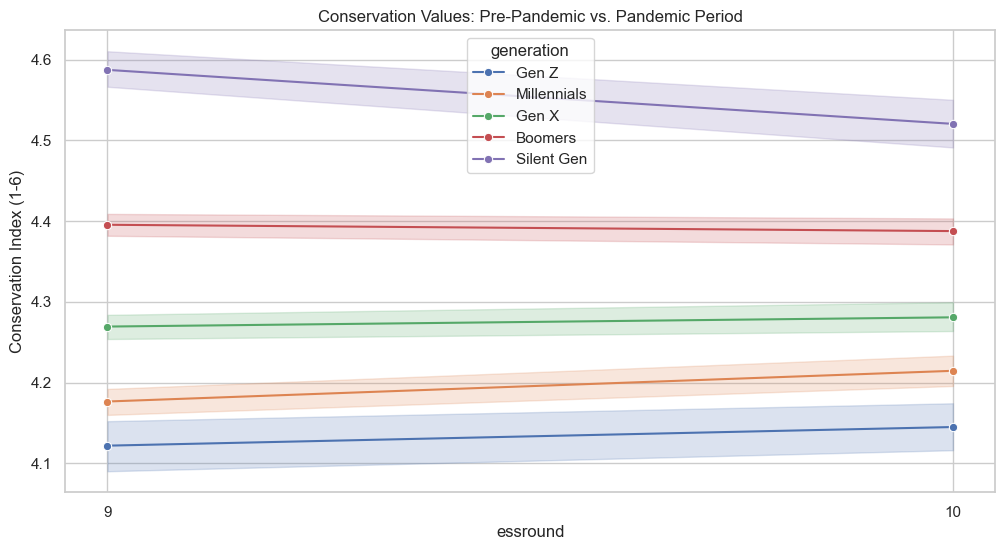

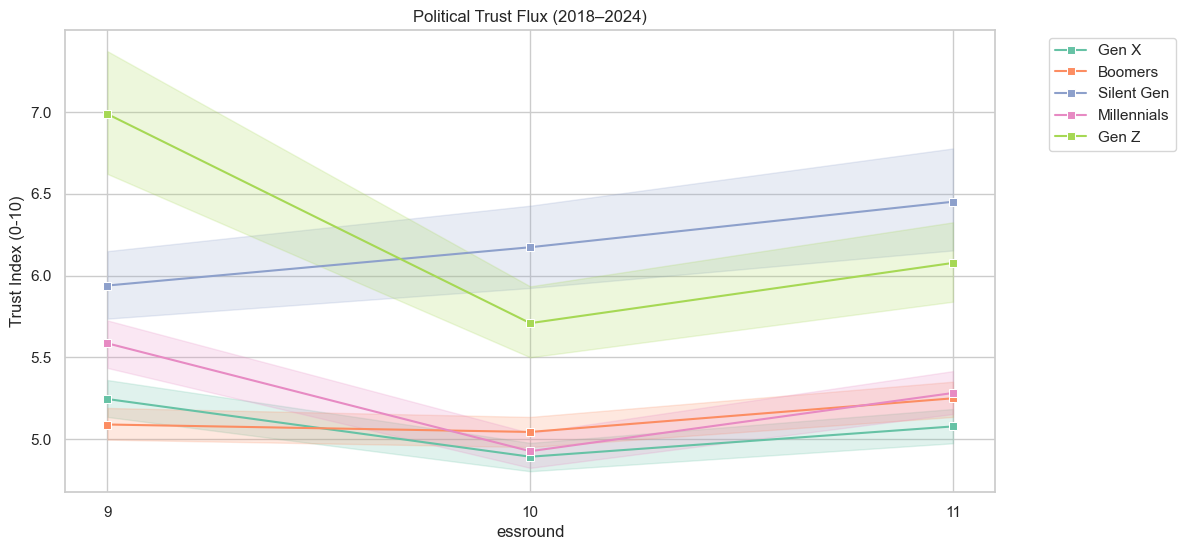

In [18]:
# Graph 1: Conservation Trend by Generation (R9 & R10 Focus)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df[df['essround'].isin([9, 10])], 
    x='essround', y='Conservation', 
    hue='generation', marker='o', 
    hue_order=['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']
)
plt.title("Conservation Values: Pre-Pandemic vs. Pandemic Period")
plt.xticks([9, 10])
plt.ylabel("Conservation Index (1-6)")
plt.show()

# Graph: Political Trust Trend (Full Timeline)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df, x='essround', y='Political_Trust', 
    hue='generation', marker='s', 
    palette='Set2'
)
plt.title("Political Trust Flux (2018–2024)")
plt.xticks([9, 10, 11])
plt.ylabel("Trust Index (0-10)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The statistical and visual analysis provides critical insights into the impact of the pandemic on European society:

**Conservation Values (2018–2022)**

The "Pandemic Shock" led to a measurable shift in Europeans' values regarding security, conformity, and tradition. As seen in the Conservation Values Trend plot, there was a noticeable movement during the height of the crisis, suggesting that individuals prioritized social order and stability as a response to global uncertainty.

The Conservation Values by Generation plot reveals that while all cohorts felt the pressure, younger generations (like Gen Z) showed a more distinct reaction to the crisis compared to the more stable baselines of older cohorts.

**Political Trust (2018–2024)**

Contrary to initial expectations, the period from 2018 to 2024 did not result in a permanent or systemic shift in trust toward political institutions.

While the Political Trust Trend plot shows a visible dip during the pandemic (Round 10), the data from Round 11 (2024) suggests a return toward pre-pandemic baselines. This indicates that institutional trust in Europe possesses a level of resilience, recovering once the immediate crisis management phase concluded.